# Loss Curve Comparison — FNO vs GINO vs GINO-VL

Reads `loss_history.json` from multiple training runs and generates a side-by-side comparison figure with training and validation loss curves for each model.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [2]:
# ---------------------------------------------------------------------------
# Configuration — edit model paths and display names here
# ---------------------------------------------------------------------------
MODELS = [
    {
        "label": "FNO",
        "path": Path("/scratch/yl75/ak4177/results/groundwater/FNO/forcing/training_20260721_092502"),
    },
    {
        "label": "GINO",
        "path": Path("/scratch/yl75/ak4177/results/groundwater/GINO/standard/training_20260715_181457"),
    },
    # {
    #     "label": "GINO-VL",
    #     "path": Path("/scratch/yl75/ak4177/results/groundwater/GINO/var_loss/training_20260713_103813"),
    # },
]

# Colour palette — one hue per model; train=solid, val=dashed
PALETTE = ["#2563EB", "#DC2626", "#16A34A"]

In [3]:
# ---------------------------------------------------------------------------
# Load all loss histories
# ---------------------------------------------------------------------------
def load_loss_history(path: Path) -> dict:
    """Load and return the loss_history.json from *path*."""
    json_file = path / "loss_history.json"
    if not json_file.exists():
        raise FileNotFoundError(f"loss_history.json not found in: {path}")
    with open(json_file) as f:
        return json.load(f)


def align_val_losses(history: dict):
    """
    Return (val_epochs, val_losses) properly aligned.

    Some runs accumulate val_losses across restarts so their flat list is
    longer than val_epochs.  In that case we take only the last
    len(val_epochs) entries, which correspond to the most recent pass.
    """
    val_epochs = history["val_epochs"]
    val_losses = history["val_losses"]
    n = len(val_epochs)
    if len(val_losses) > n:
        val_losses = val_losses[-n:]
    return np.array(val_epochs), np.array(val_losses)


records = []
for m in MODELS:
    h = load_loss_history(m["path"])
    train_epochs = np.arange(1, len(h["train_losses"]) + 1)
    val_epochs, val_losses = align_val_losses(h)
    records.append({
        "label": m["label"],
        "train_epochs": train_epochs,
        "train_losses": np.array(h["train_losses"]),
        "val_epochs": val_epochs,
        "val_losses": val_losses,
        "total_epochs": h["total_epochs"],
    })
    print(f"{m['label']:35s}  "
          f"train={len(h['train_losses'])} epochs  "
          f"val={len(val_losses)} checkpoints")

FNO                                  train=500 epochs  val=50 checkpoints
GINO                                 train=500 epochs  val=52 checkpoints


In [4]:
# ---------------------------------------------------------------------------
# Model size — number of parameters from the latest checkpoint
# ---------------------------------------------------------------------------
import torch

def count_parameters(checkpoint_path: Path) -> int:
    """
    Load a .pth checkpoint and return the total number of parameters
    stored in model_state_dict (or state_dict if that key is absent).
    """
    ck = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    if "model_state_dict" in ck:
        sd = ck["model_state_dict"]
    elif "state_dict" in ck:
        sd = ck["state_dict"]
    else:
        sd = ck  # checkpoint IS the state dict
    return sum(t.numel() for t in sd.values() if hasattr(t, "numel"))


def find_latest_checkpoint(training_path: Path) -> Path:
    """
    Return the latest_checkpoint.pth under *training_path/checkpoints/*.
    Falls back to final_checkpoint.pth if latest is absent.
    """
    ckpt_dir = training_path / "checkpoints"
    for name in ("latest_checkpoint.pth", "final_checkpoint.pth"):
        p = ckpt_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(f"No checkpoint found in {ckpt_dir}")


print(f"{'Model':<12} {'Checkpoint':<30} {'Parameters':>15} {'Params (M)':>12}")
print("-" * 72)
for m in MODELS:
    ckpt = find_latest_checkpoint(m["path"])
    n_params = count_parameters(ckpt)
    print(f"{m['label']:<12} {ckpt.name:<30} {n_params:>15,} {n_params/1e6:>11.2f}M")
    m["n_params"] = n_params  # store for use in plot titles

Model        Checkpoint                          Parameters   Params (M)
------------------------------------------------------------------------
FNO          latest_checkpoint.pth               33,663,298       33.66M
GINO         latest_checkpoint.pth               33,701,008       33.70M


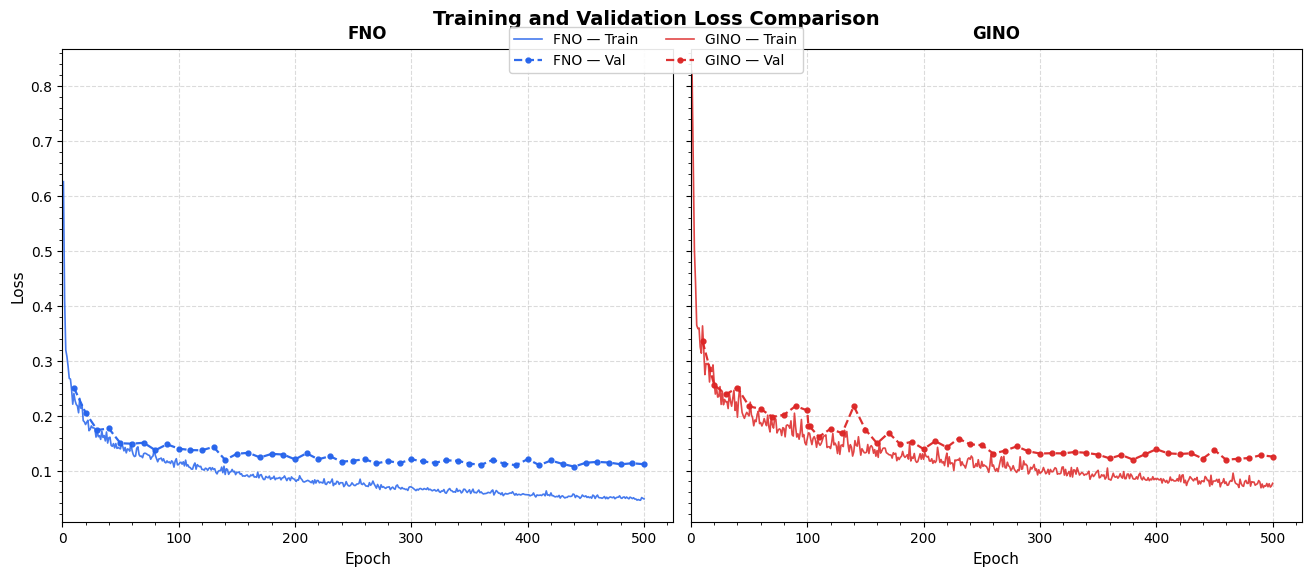

Figure saved to loss_comparison_subplots.png


In [6]:
# ---------------------------------------------------------------------------
# Figure — one subplot per model, shared y-axis, combined legend at the top
# ---------------------------------------------------------------------------
n_models = len(records)

fig, axes = plt.subplots(
    1, n_models,
    figsize=(6.5 * n_models, 5.5),
    sharey=True,
    constrained_layout=True,
)

# Make axes always iterable even for a single model
if n_models == 1:
    axes = [axes]

legend_handles = []

for ax, rec, color in zip(axes, records, PALETTE):
    # Training loss
    h_train, = ax.plot(
        rec["train_epochs"], rec["train_losses"],
        color=color, linewidth=1.2, alpha=0.85,
        label=f"{rec['label']} — Train",
    )
    # Validation loss
    h_val, = ax.plot(
        rec["val_epochs"], rec["val_losses"],
        color=color, linewidth=1.6, linestyle="--",
        marker="o", markersize=3.5, alpha=0.95,
        label=f"{rec['label']} — Val",
    )

    legend_handles.extend([h_train, h_val])

    ax.set_title(rec["label"], fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_xlim(left=0)
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(axis="both", which="major", labelsize=10)

axes[0].set_ylabel("Loss", fontsize=11)

fig.suptitle(
    "Training and Validation Loss Comparison",
    fontsize=14, fontweight="bold", y=1.02,
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=n_models,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#cccccc",
)

plt.savefig("loss_comparison_subplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to loss_comparison_subplots.png")

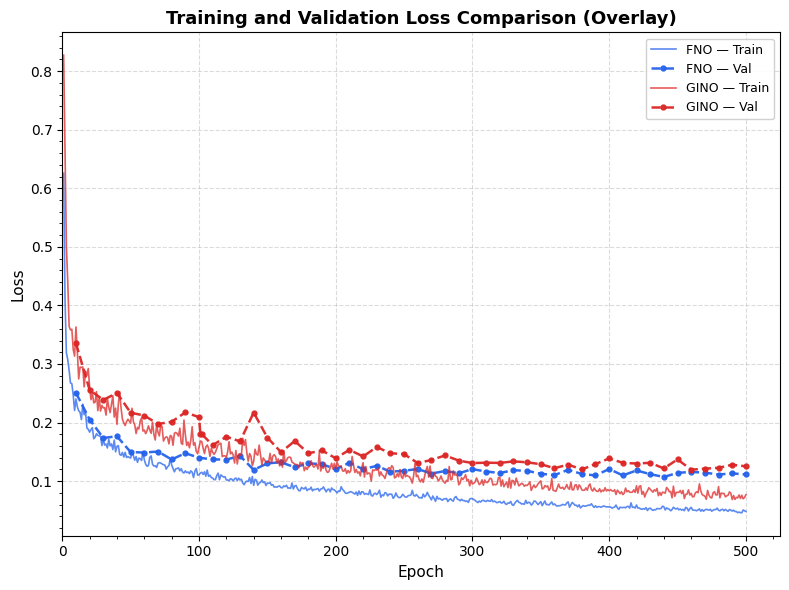

Overlay figure saved to loss_comparison_overlay.png


In [8]:
# ---------------------------------------------------------------------------
# Single-panel overlay — all models on one axes
# ---------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))

for rec, color in zip(records, PALETTE):
    ax2.plot(
        rec["train_epochs"], rec["train_losses"],
        color=color, linewidth=1.2, alpha=0.75,
        label=f"{rec['label']} — Train",
    )
    ax2.plot(
        rec["val_epochs"], rec["val_losses"],
        color=color, linewidth=1.8, linestyle="--",
        marker="o", markersize=3.5, alpha=0.95,
        label=f"{rec['label']} — Val",
    )

ax2.set_title("Training and Validation Loss Comparison (Overlay)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Loss", fontsize=11)
ax2.set_xlim(left=0)
ax2.grid(True, linestyle="--", alpha=0.45)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.tick_params(axis="both", labelsize=10)
ax2.legend(fontsize=9, framealpha=0.9, edgecolor="#cccccc",
           loc="upper right", ncol=1)

plt.tight_layout()
plt.savefig("loss_comparison_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Overlay figure saved to loss_comparison_overlay.png")